In [7]:
import gc
import json 
from pathlib import Path
import torch
import torch.nn.functional as F
from diffusers import FluxPipeline
import argparse
import random
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_regression

In [8]:
import numpy as np
import torch
from sklearn.metrics import mutual_info_score

# ============================================================
# MUTUAL INFORMATION (Memory-Efficient)
# ============================================================
def calculate_mutual_information(QK_p, QK_n, bins=30, sample_size=10000):
    """
    Memory-efficient Mutual Information zwischen zwei Attention Maps
    
    Args:
        QK_p: Positive attention map
        QK_n: Negative attention map
        bins: Anzahl der Bins für Diskretisierung
        sample_size: Max. Anzahl Samples (subsampling wenn größer)
    """
    # Flatten und zu numpy konvertieren
    p_flat = QK_p.detach().cpu().numpy().flatten()
    n_flat = QK_n.detach().cpu().numpy().flatten()
    
    # Subsampling wenn zu groß
    if len(p_flat) > sample_size:
        indices = np.random.choice(len(p_flat), sample_size, replace=False)
        p_flat = p_flat[indices]
        n_flat = n_flat[indices]
    
    # Diskretisierung
    p_discrete = np.digitize(p_flat, bins=np.linspace(p_flat.min(), p_flat.max(), bins))
    n_discrete = np.digitize(n_flat, bins=np.linspace(n_flat.min(), n_flat.max(), bins))
    
    mi = mutual_info_score(p_discrete, n_discrete)
    
    return mi


# ============================================================
# CKA (Memory-Efficient - Simple Version)
# ============================================================
def simple_CKA(X, Y):
    """
    Memory-efficient CKA: Vergleicht über Batch/Head Dimension statt Features
    
    Args:
        X, Y: torch.Tensor of shape (batch, heads, seq1, seq2)
    
    Returns:
        CKA similarity score (0 to 1)
    """
    # Reshape: (seq1*seq2, batch*heads) statt (batch*heads, seq1*seq2)
    b, h, s1, s2 = X.shape
    
    X_reshaped = X.permute(2, 3, 0, 1).reshape(s1 * s2, b * h)  # (positions, samples)
    Y_reshaped = Y.permute(2, 3, 0, 1).reshape(s1 * s2, b * h)
    
    X_np = X_reshaped.detach().cpu().numpy().astype(np.float32)
    Y_np = Y_reshaped.detach().cpu().numpy().astype(np.float32)
    
    # Zentrierung
    X_np = X_np - X_np.mean(axis=0, keepdims=True)
    Y_np = Y_np - Y_np.mean(axis=0, keepdims=True)
    
    # Gram Matrizen (samples, samples) - viel kleiner!
    XtX = X_np.T @ X_np
    YtY = Y_np.T @ Y_np
    
    # CKA Berechnung
    numerator = np.linalg.norm(X_np.T @ Y_np, 'fro') ** 2
    denominator = np.linalg.norm(XtX, 'fro') * np.linalg.norm(YtY, 'fro')
    
    if denominator < 1e-10:
        return 0.0
    
    return numerator / denominator


# ============================================================
# ALTERNATIVE: Normalized Correlation (noch schneller)
# ============================================================
def normalized_correlation(X, Y):
    """
    Normalized correlation - ähnlich wie CKA aber effizienter
    
    Args:
        X, Y: torch.Tensor (any shape)
    
    Returns:
        Correlation coefficient (-1 to 1)
    """
    X_flat = X.reshape(-1)
    Y_flat = Y.reshape(-1)
    
    X_centered = X_flat - X_flat.mean()
    Y_centered = Y_flat - Y_flat.mean()
    
    numerator = torch.sum(X_centered * Y_centered)
    denominator = torch.sqrt(torch.sum(X_centered ** 2) * torch.sum(Y_centered ** 2))
    
    if denominator < 1e-10:
        return 0.0
    
    return (numerator / denominator).item()



In [9]:
pipe = FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-dev", torch_dtype=torch.float16)
pipe.enable_model_cpu_offload()

KeyboardInterrupt: 

In [ ]:
!nvidia-smi

In [ ]:
# Register hooks
qs_img = []
ks_img = []
qs_txt = []
ks_txt = [] 

def register_hooks(transformer):
    # Hook normalized queries and keys for image tokens
    def hook_img_q(module, input, output):
        qs_img.append(output.detach())  
    def hook_img_k(module, input, output):
        ks_img.append(output.detach())  
    # Hook normalized queries and keys for text tokens
    def hook_txt_q(module, input, output):
        qs_txt.append(output.detach())  
    def hook_txt_k(module, input, output):
        ks_txt.append(output.detach())  
    for i, block in enumerate(transformer.transformer_blocks):
        block.attn.norm_q.register_forward_hook(hook_img_q)
        block.attn.norm_k.register_forward_hook(hook_img_k)
        block.attn.norm_added_q.register_forward_hook(hook_txt_q)
        block.attn.norm_added_k.register_forward_hook(hook_txt_k)
        print(f'Successfully registered QK hooks for block {i}.')

register_hooks(pipe.transformer)

Successfully registered QK hooks for block 0.
Successfully registered QK hooks for block 1.
Successfully registered QK hooks for block 2.
Successfully registered QK hooks for block 3.
Successfully registered QK hooks for block 4.
Successfully registered QK hooks for block 5.
Successfully registered QK hooks for block 6.
Successfully registered QK hooks for block 7.
Successfully registered QK hooks for block 8.
Successfully registered QK hooks for block 9.
Successfully registered QK hooks for block 10.
Successfully registered QK hooks for block 11.
Successfully registered QK hooks for block 12.
Successfully registered QK hooks for block 13.
Successfully registered QK hooks for block 14.
Successfully registered QK hooks for block 15.
Successfully registered QK hooks for block 16.
Successfully registered QK hooks for block 17.
Successfully registered QK hooks for block 18.


In [ ]:
# Set up metrics
num_layers = 19
num_steps = 28
dataset = json.load(open('/export/home/ru63zus/repos/contrastive-skip-layer-guidance/prompt_datasets/text/text_pairs_simple.json', "r"))
num_seeds = 1
all_metrics = {
    "cos_t2t": torch.zeros(len(dataset), num_seeds, num_layers, num_steps),
    "cos_t2i": torch.zeros(len(dataset), num_seeds, num_layers, num_steps),
    "cos_i2t": torch.zeros(len(dataset), num_seeds, num_layers, num_steps),
    "cos_i2i": torch.zeros(len(dataset), num_seeds, num_layers, num_steps),
    "abs_t2t": torch.zeros(len(dataset), num_seeds, num_layers, num_steps),
    "abs_t2i": torch.zeros(len(dataset), num_seeds, num_layers, num_steps),
    "abs_i2t": torch.zeros(len(dataset), num_seeds, num_layers, num_steps),
    "abs_i2i": torch.zeros(len(dataset), num_seeds, num_layers, num_steps),
    "l2_t2t": torch.zeros(len(dataset), num_seeds, num_layers, num_steps),
    "l2_t2i": torch.zeros(len(dataset), num_seeds, num_layers, num_steps),
    "l2_i2t": torch.zeros(len(dataset), num_seeds, num_layers, num_steps),
    "l2_i2i": torch.zeros(len(dataset), num_seeds, num_layers, num_steps),
    # Neue Metriken: Mutual Information
    "mi_t2t": np.zeros((len(dataset), num_seeds, num_layers, num_steps)),
    "mi_t2i": np.zeros((len(dataset), num_seeds, num_layers, num_steps)),
    "mi_i2t": np.zeros((len(dataset), num_seeds, num_layers, num_steps)),
    "mi_i2i": np.zeros((len(dataset), num_seeds, num_layers, num_steps)),
    
    # Neue Metriken: CKA
    "cka_t2t": np.zeros((len(dataset), num_seeds, num_layers, num_steps)),
    "cka_t2i": np.zeros((len(dataset), num_seeds, num_layers, num_steps)),
    "cka_i2t": np.zeros((len(dataset), num_seeds, num_layers, num_steps)),
    "cka_i2i": np.zeros((len(dataset), num_seeds, num_layers, num_steps)),
    }

In [ ]:
def cleanup(): 
    qs_img.clear()
    ks_img.clear()
    qs_txt.clear()
    ks_txt.clear()
    torch.cuda.empty_cache()
    gc.collect()

def safe_cosine(a, b, eps=1e-8, nan_to=0.0):
    vec1 = a.reshape(-1)
    vec2 = b.reshape(-1)
    if torch.norm(vec1).item() == 0.0 and torch.norm(vec2).item() == 0.0:
        return 1.0
    if torch.norm(vec1).item() == 0.0 or torch.norm(vec2).item() == 0.0:
        return 0.0
    cos = F.cosine_similarity(vec1, vec2, dim=0, eps=eps)
    if torch.isnan(cos):
        raise ValueError('Cosine Similarity is None.')
    return cos.item()

with torch.no_grad():
    for di, pair in enumerate(dataset[:5]):
        for seed_i in range(1):
            random_seed = random.randint(0, 2**32 - 1)

            # Forward with positive prompt (with target)
            _ = pipe(
                pair["positive"],
                num_inference_steps=num_steps,
                max_sequence_length=256,
                generator=torch.Generator("cpu").manual_seed(random_seed)
            )     

            q_img_p = [q for q in qs_img]
            k_img_p = [k for k in ks_img]
            q_txt_p = [q for q in qs_txt]
            k_txt_p = [k for k in ks_txt]
            cleanup()

            # Forward with negative prompt (without target)
            _ = pipe(
                pair["negative"],
                num_inference_steps=num_steps,
                max_sequence_length=256,
                generator=torch.Generator("cpu").manual_seed(random_seed)
            )

            q_img_n = [q for q in qs_img]
            k_img_n = [k for k in ks_img]
            q_txt_n = [q for q in qs_txt]
            k_txt_n = [k for k in ks_txt]
            cleanup()

            for layer in range(num_layers):
                for step in range(num_steps):
                    Q_img_p = q_img_p[step * num_layers + layer]
                    K_img_p = k_img_p[step * num_layers + layer]
                    Q_txt_p = q_txt_p[step * num_layers + layer]
                    K_txt_p = k_txt_p[step * num_layers + layer]

                    Q_img_n = q_img_n[step * num_layers + layer]
                    K_img_n = k_img_n[step * num_layers + layer]
                    Q_txt_n = q_txt_n[step * num_layers + layer]
                    K_txt_n = k_txt_n[step * num_layers + layer]

                    Q_merged_p = torch.cat([Q_txt_p, Q_img_p], dim=1)  
                    K_merged_p = torch.cat([K_txt_p, K_img_p], dim=1)         
                    Q_merged_n = torch.cat([Q_txt_n, Q_img_n], dim=1)  
                    K_merged_n = torch.cat([K_txt_n, K_img_n], dim=1)   

                    del Q_img_p, K_img_p, Q_txt_p, K_txt_p, Q_img_n, K_img_n, Q_txt_n, K_txt_n

                    QK_p_merged = torch.einsum('bihd,bjhd->bhij', Q_merged_p, K_merged_p) / (Q_merged_p.shape[-1] ** 0.5)
                    QK_n_merged = torch.einsum('bihd,bjhd->bhij', Q_merged_n, K_merged_n) / (Q_merged_n.shape[-1] ** 0.5)
                    QK_p = torch.softmax(QK_p_merged, dim=-1)
                    QK_n = torch.softmax(QK_n_merged, dim=-1)

                    QK_diff = QK_p - QK_n                      

                    # Calculate Metrics
                    # Text-2-Text
                    all_metrics["l2_t2t"][di, seed_i, layer, step] = torch.sqrt(torch.sum(QK_diff[:, :, :256, :256] ** 2)).item()
                    all_metrics["abs_t2t"][di, seed_i, layer, step] = (torch.sum(QK_p[:, :, :256, :256]) - torch.sum(QK_n[:, :, :256, :256])).item()    
                    all_metrics["cos_t2t"][di, seed_i, layer, step] = safe_cosine(
                        QK_p[:, :, :256, :256].reshape(-1),
                        QK_n[:, :, :256, :256].reshape(-1),
                    )

                    # Text-2-Image
                    all_metrics["l2_t2i"][di, seed_i, layer, step] = torch.sqrt(torch.sum(QK_diff[:, :, :256, 256:] ** 2)).item()
                    all_metrics["abs_t2i"][di, seed_i, layer, step] = (torch.sum(QK_p[:, :, :256, 256:]) - torch.sum(QK_n[:, :, :256, 256:])).item()    
                    all_metrics["cos_t2i"][di, seed_i, layer, step] = safe_cosine(
                        QK_p[:, :, :256, 256:].reshape(-1),
                        QK_n[:, :, :256, 256:].reshape(-1),
                    )

                    # Image-2-Text
                    all_metrics["l2_i2t"][di, seed_i, layer, step] = torch.sqrt(torch.sum(QK_diff[:, :, 256:, :256] ** 2)).item()
                    all_metrics["abs_i2t"][di, seed_i, layer, step] = (torch.sum(QK_p[:, :, 256:, :256]) - torch.sum(QK_n[:, :, 256:, :256])).item()    
                    all_metrics["cos_i2t"][di, seed_i, layer, step] = safe_cosine(
                        QK_p[:, :, 256:, :256].reshape(-1),
                        QK_n[:, :, 256:, :256].reshape(-1),
                    )

                    # Image-2-Image
                    all_metrics["l2_i2i"][di, seed_i, layer, step] = torch.sqrt(torch.sum(QK_diff[:, :, 256:, 256:] ** 2)).item()
                    all_metrics["abs_i2i"][di, seed_i, layer, step] = (torch.sum(QK_p[:, :, 256:, 256:]) - torch.sum(QK_n[:, :, 256:, 256:])).item()    
                    all_metrics["cos_i2i"][di, seed_i, layer, step] = safe_cosine(
                        QK_p[:, :, 256:, 256:].reshape(-1),
                        QK_n[:, :, 256:, 256:].reshape(-1),
                    )

                    del QK_p_merged, QK_n_merged, QK_p, QK_n, QK_diff
                    torch.cuda.empty_cache()
                    gc.collect()

            # Clean up GPU tensors after processing this seed
            del q_img_p, k_img_p, q_txt_p, k_txt_p
            del q_img_n, k_img_n, q_txt_n, k_txt_n
            torch.cuda.empty_cache()
            gc.collect()

  0%|          | 0/28 [00:00<?, ?it/s]

torch.Size([1, 4096, 24, 128])
torch.Size([1, 4096, 24, 128])
torch.Size([1, 256, 24, 128])
torch.Size([1, 256, 24, 128])


  0%|          | 0/28 [00:00<?, ?it/s]

KeyboardInterrupt: 

cos_t2t: correlation = -0.4263


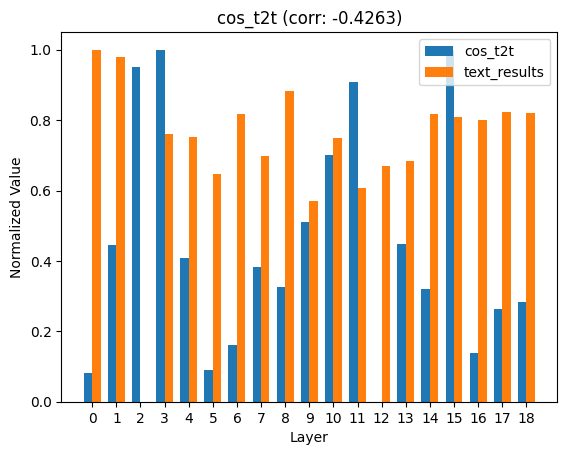

cos_t2i: correlation = -0.0471


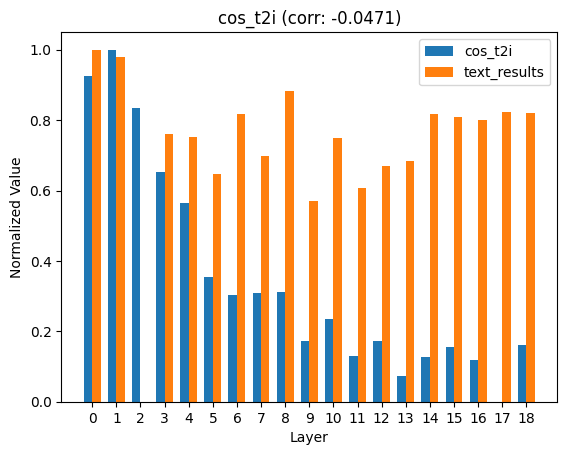

cos_i2t: correlation = -0.3004


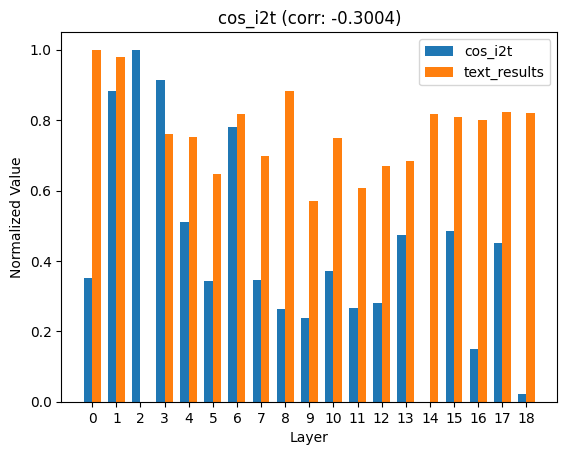

cos_i2i: correlation = -0.0534


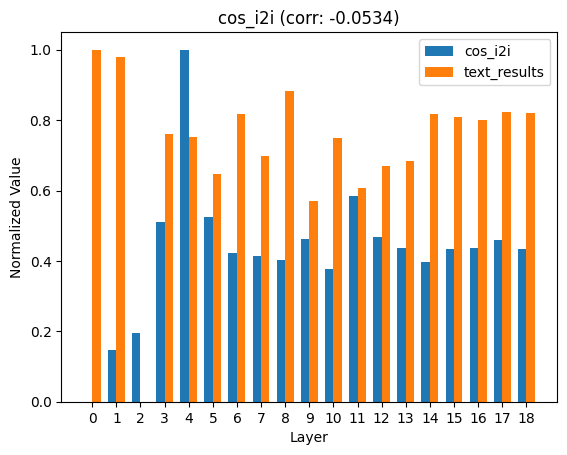

abs_t2t: correlation = -0.2176


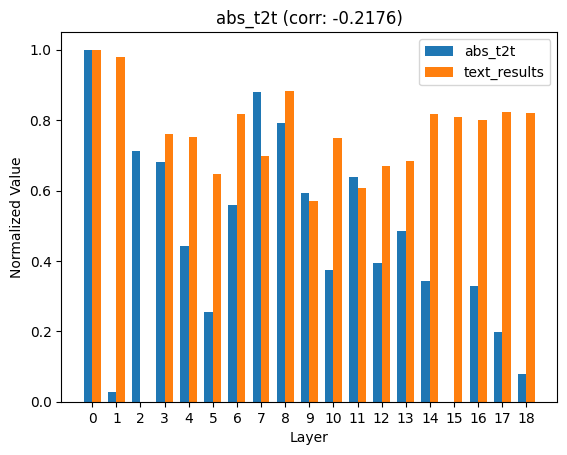

abs_t2i: correlation = 0.2187


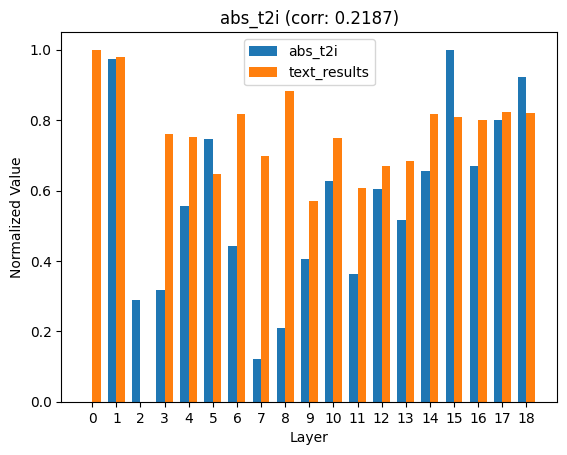

abs_i2t: correlation = -0.0680


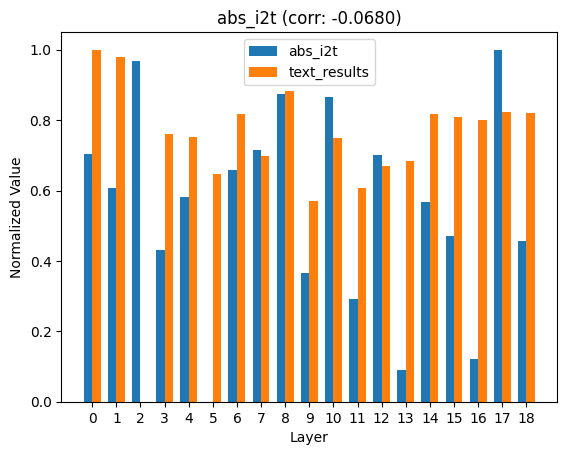

abs_i2i: correlation = nan


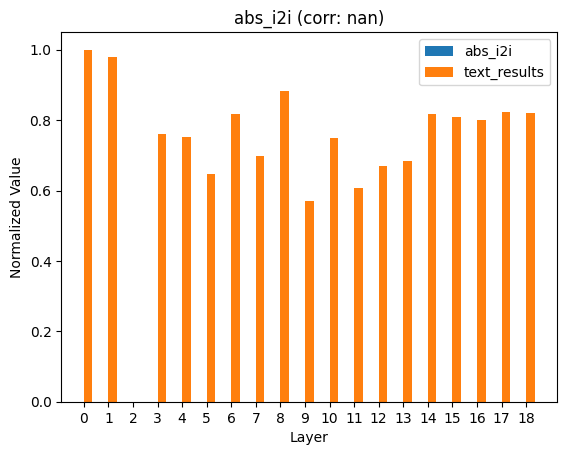

l2_t2t: correlation = 0.3961


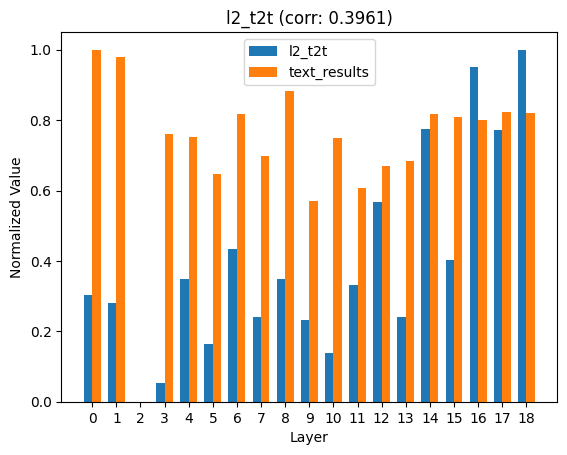

l2_t2i: correlation = -0.0076


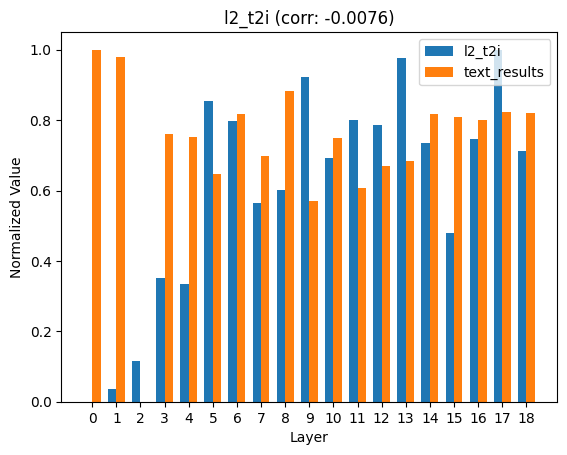

l2_i2t: correlation = 0.1141


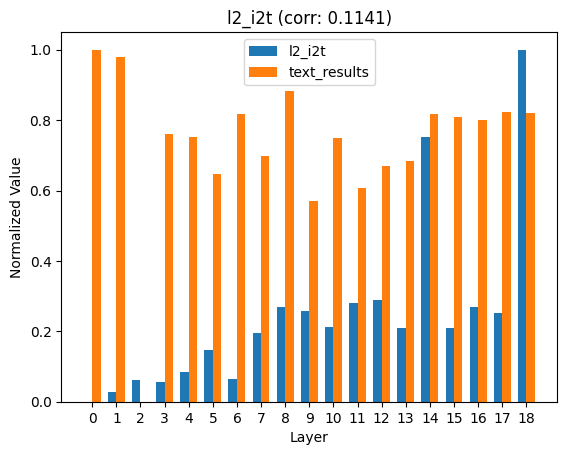

l2_i2i: correlation = 0.0025


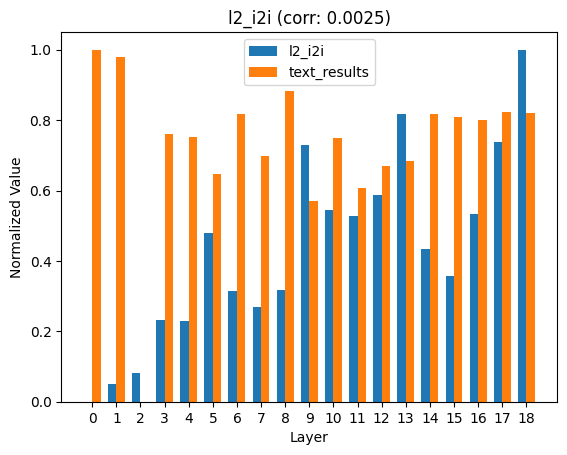

In [ ]:
start = 8
end = 18

avg_metrics_per_layer = {
        metric: all_metrics[metric][:5,:,:,start:end].mean(dim=(0, 1, 3)) 
        for metric in all_metrics
}

avg_metrics_early_layers = {
        metric: all_metrics[metric][:5,:,:,start:end].mean(dim=(0, 1, 3)) 
        for metric in all_metrics
}

avg_metrics_middle_layers = {
        metric: all_metrics[metric][:5,:,:,start:end].mean(dim=(0, 1, 3)) 
        for metric in all_metrics
}

avg_metrics_late_layers = {
        metric: all_metrics[metric][:5,:,:,start:end].mean(dim=(0, 1, 3)) 
        for metric in all_metrics
}
text_results = torch.tensor([0.231960, 0.230319, 0.147445, 0.211755, 0.210885, 
                     0.202199, 0.216633, 0.206342, 0.222167, 0.195722, 
                     0.210882, 0.198651, 0.204099, 0.205225, 0.216540, 
                     0.215737, 0.215030, 0.216897, 0.216760])

# Normalize text_results once
text_norm = (text_results - text_results.min()) / (text_results.max() - text_results.min())

for metric in avg_metrics_per_layer.keys():
    data = avg_metrics_per_layer[metric]
    # Normalize data to [0, 1]
    data_norm = (data - data.min()) / (data.max() - data.min())
    
    # Calculate correlation
    correlation = np.corrcoef(data_norm.numpy(), text_norm.numpy())[0, 1]
    print(f"{metric}: correlation = {correlation:.4f}")
    
    x = np.arange(len(data_norm))
    width = 0.35  # Width of bars
    
    plt.bar(x - width/2, data_norm, width, label=metric)
    plt.bar(x + width/2, text_norm, width, label='text_results')
    plt.xlabel('Layer')
    plt.ylabel('Normalized Value')
    plt.xticks(x)
    plt.legend()
    plt.title(f'{metric} (corr: {correlation:.4f})')
    plt.show()